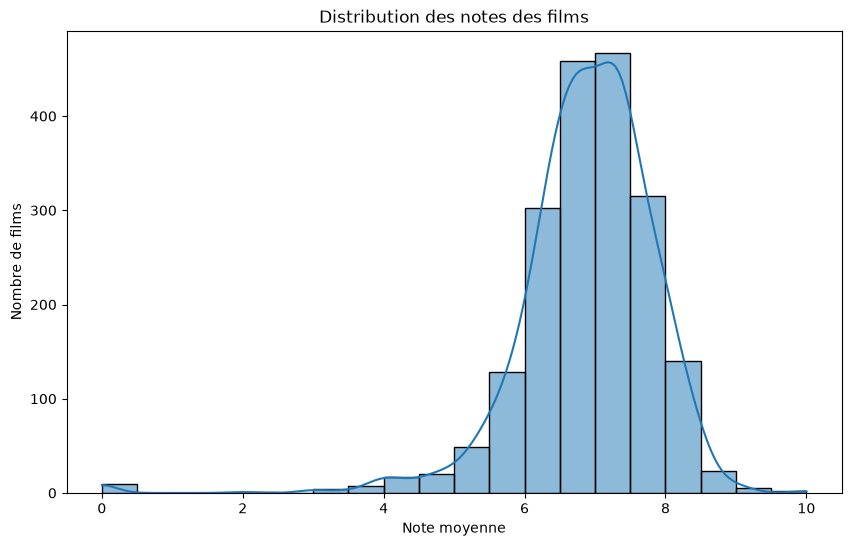

In [31]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.analysis import getAllMovies

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


movies = list(getAllMovies())
df = pd.DataFrame(movies)

plt.figure(figsize=(10, 6))

# notes des films
sns.histplot(
    data=df,
    x="vote_average",
    bins=20,
    kde=True
)

plt.title("Distribution des notes des films")
plt.xlabel("Note moyenne")
plt.ylabel("Nombre de films")

plt.show()

    



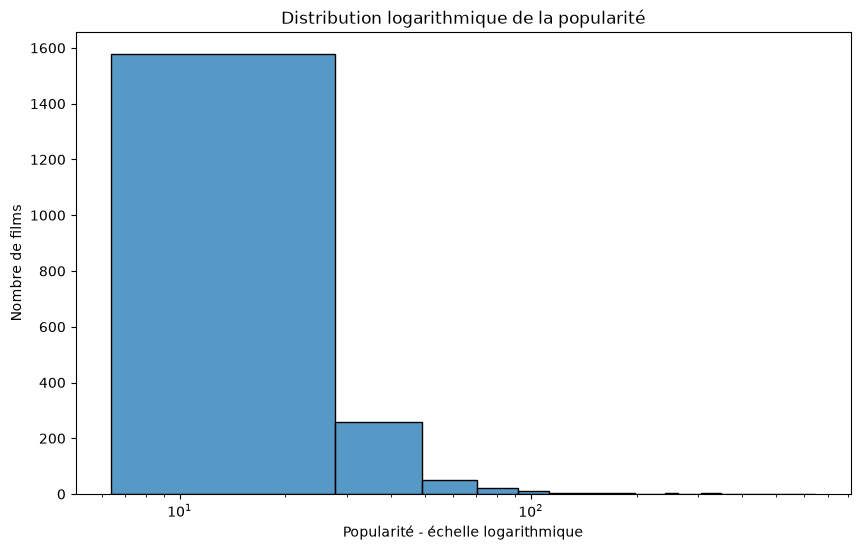

In [14]:
# la popularite des films
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="popularity",
    bins=30
)
plt.xscale("log")

plt.title("Distribution logarithmique de la popularité")
plt.xlabel("Popularité - échelle logarithmique")
plt.ylabel("Nombre de films")

plt.show()

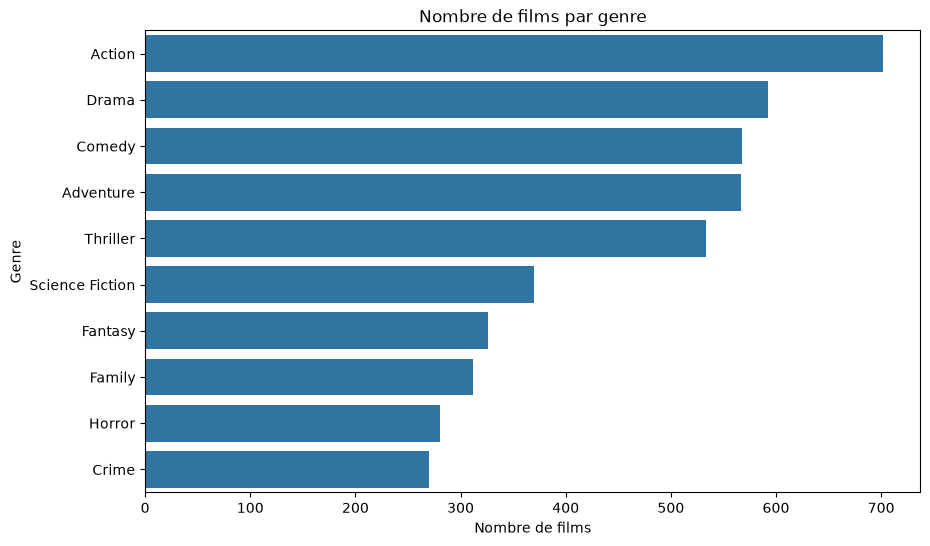

In [15]:
df_genres = df.explode("genres")

genre_counts = (
    df_genres["genres"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index
)

plt.title("Nombre de films par genre")
plt.xlabel("Nombre de films")
plt.ylabel("Genre")

plt.show()

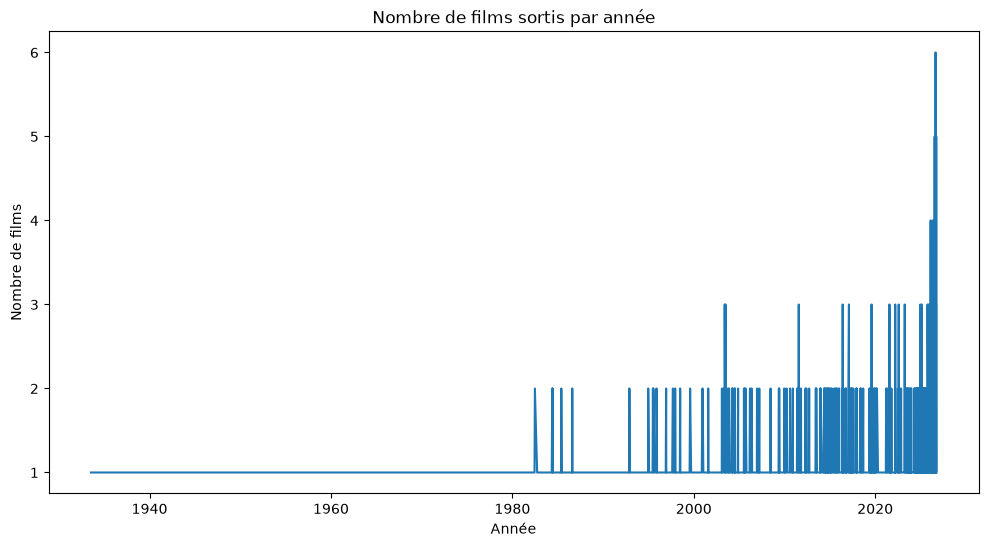

In [16]:
movies_by_date = (
    df.groupby("release_date")
      .size()
      .reset_index(name="count")
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=movies_by_date,
    x="release_date",
    y="count"
)

plt.title("Nombre de films sortis par année")
plt.xlabel("Année")
plt.ylabel("Nombre de films")

plt.show()

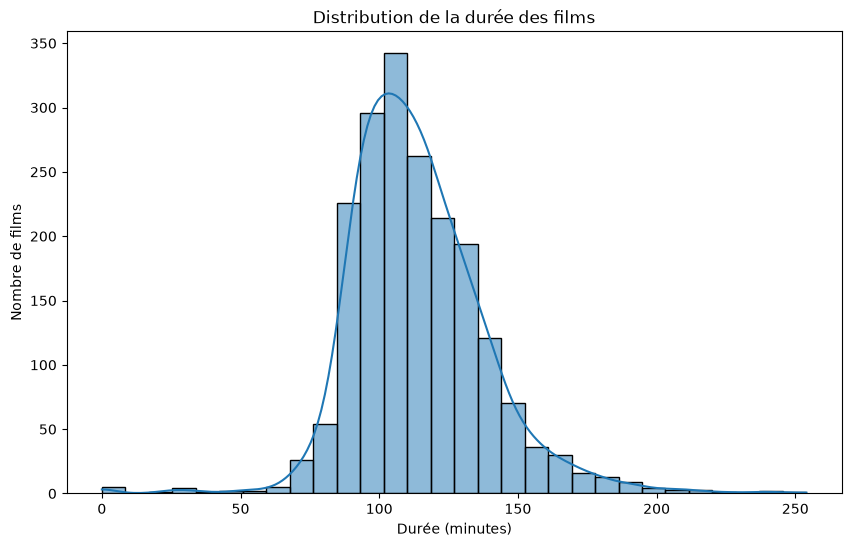

In [17]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="runtime",
    bins=30,
    kde=True
)

plt.title("Distribution de la durée des films")
plt.xlabel("Durée (minutes)")
plt.ylabel("Nombre de films")

plt.show()

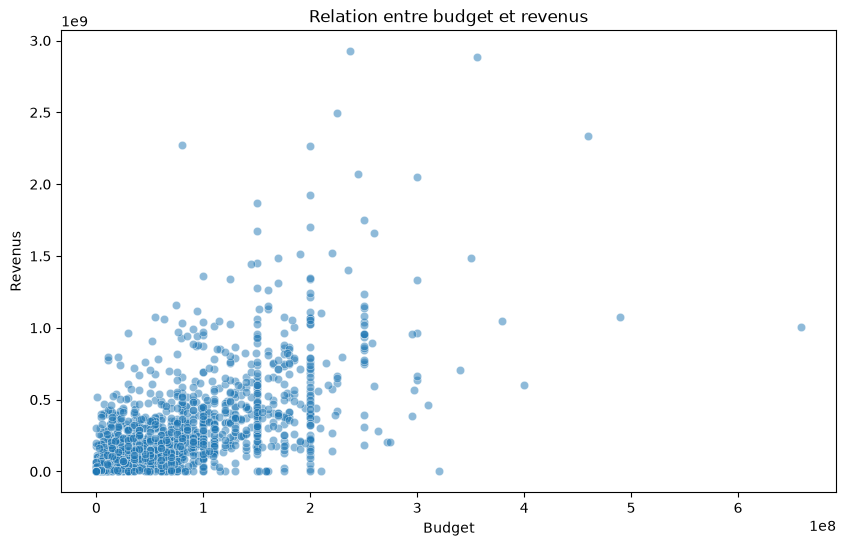

In [20]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="budget",
    y="revenue",
    alpha=0.5
)

plt.title("Relation entre budget et revenus")
plt.xlabel("Budget")
plt.ylabel("Revenus")

plt.show()

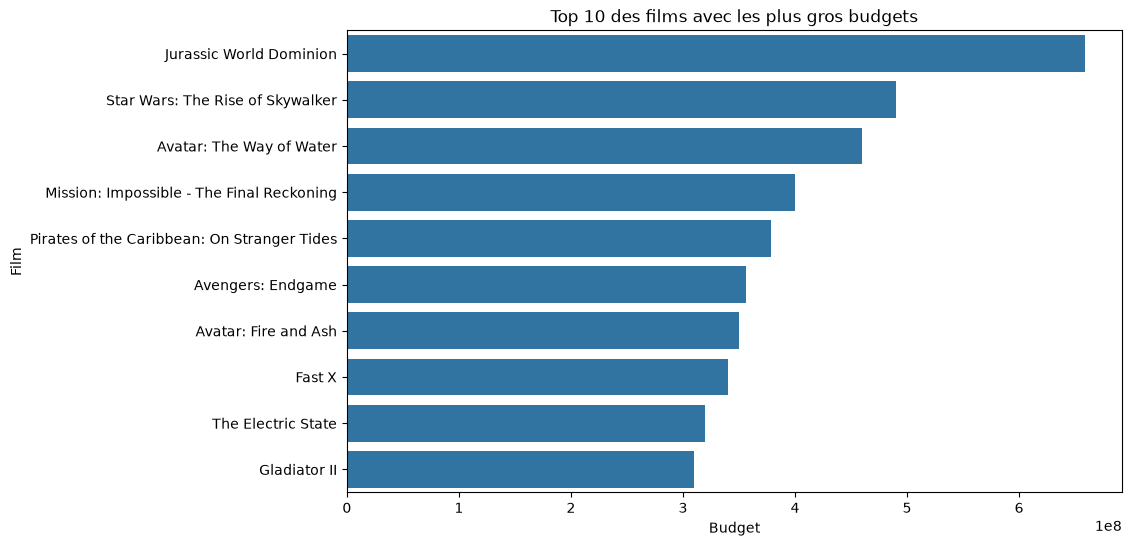

In [22]:
top_budget = (
    df.nlargest(10, "budget")
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_budget,
    x="budget",
    y="title"
)

plt.title("Top 10 des films avec les plus gros budgets")
plt.xlabel("Budget")
plt.ylabel("Film")

plt.show()

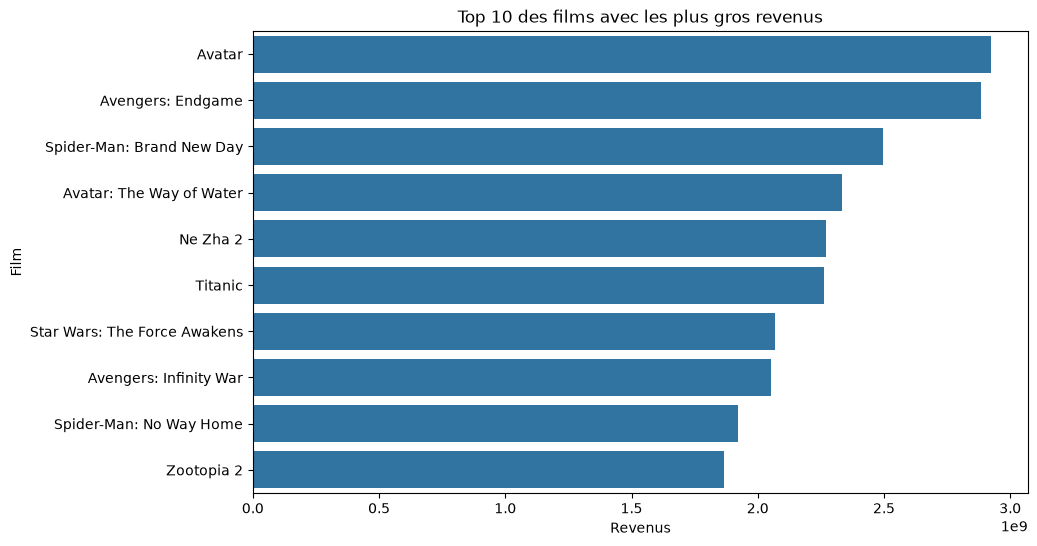

In [23]:
top_revenue = (
    df.nlargest(10, "revenue")
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_revenue,
    x="revenue",
    y="title"
)

plt.title("Top 10 des films avec les plus gros revenus")
plt.xlabel("Revenus")
plt.ylabel("Film")

plt.show()

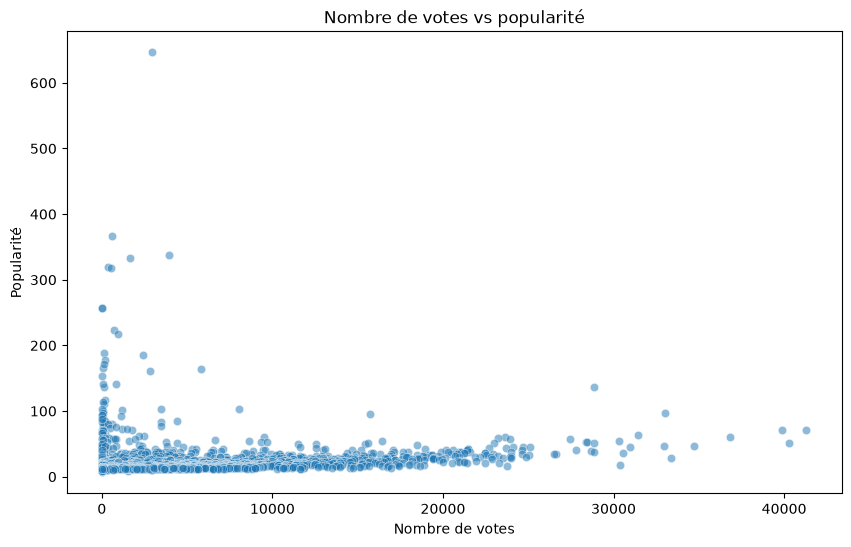

In [24]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="vote_count",
    y="popularity",
    alpha=0.5
)

plt.title("Nombre de votes vs popularité")
plt.xlabel("Nombre de votes")
plt.ylabel("Popularité")

plt.show()

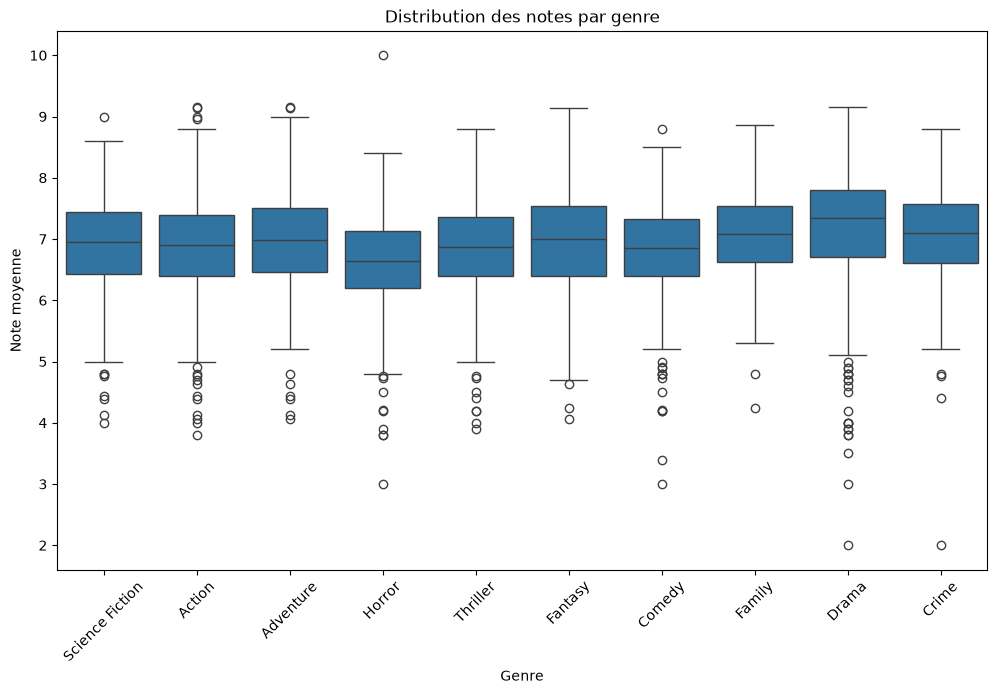

In [26]:
df_genres = df.explode("genres")

top_genres = (
    df_genres["genres"]
    .value_counts()
    .head(10)
    .index
)

df_top_genres = df_genres[
    df_genres["genres"].isin(top_genres)
]

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df_top_genres,
    x="genres",
    y="vote_average"
)

plt.xticks(rotation=45)

plt.title("Distribution des notes par genre")
plt.xlabel("Genre")
plt.ylabel("Note moyenne")

plt.show()

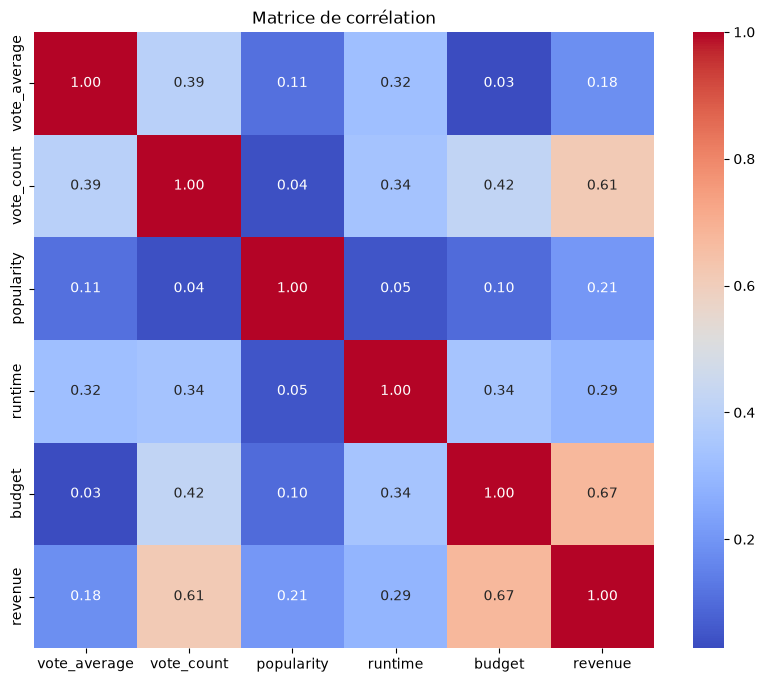

In [27]:
numeric_cols = [
    "vote_average",
    "vote_count",
    "popularity",
    "runtime",
    "budget",
    "revenue"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matrice de corrélation")

plt.show()

In [ ]:
df["release_year"] = df["release_date"].dt.year
df["release_month"] = df["release_date"].dt.month
df["release_day"] = df["release_date"].dt.day


0       2026
1       2026
2       2026
3       2026
4       2026
        ... 
1942    2026
1943    2017
1944    2017
1945    2003
1946    2004
Name: release_year, Length: 1947, dtype: int32
0       7
1       9
2       8
3       7
4       9
       ..
1942    9
1943    3
1944    3
1945    2
1946    8
Name: release_month, Length: 1947, dtype: int32
0       29
1       16
2       12
3       15
4       23
        ..
1942    25
1943    23
1944     2
1945    14
1946     4
Name: release_day, Length: 1947, dtype: int32
